# Лабораторная работа №4 - Рекомендательная система модных товаров

В данной лабораторной работе мы создадим рекомендательную систему по схожести товаров на основе Fashion Product Images Dataset с использованием нескольких методов машинного обучения.

## Задачи:
1. Загрузить датасет «Fashion Product Images Dataset»
2. Провести EDA анализ датасета
3. Построить рекомендательную систему с несколькими методами машинного обучения (минимум 3)
4. Выбрать лучшую модель и сохранить её в оптимальном формате
5. Создать пользовательский интерфейс рекомендательной системы

In [ ]:
%pip install pillow scikit-learn torch torchvision seaborn kaggle --quiet

import os
import kaggle

os.environ['KAGGLE_USERNAME'] = 'gretazh'
os.environ['KAGGLE_KEY'] = '7e4b8ddc7fdc96f34b0e0c93d53badf0'

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import json
from pathlib import Path
import requests
import zipfile
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
import pickle
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn


Основные библиотеки импортированы успешно!
PyTorch импортирован успешно!


In [ ]:
def download_fashion_dataset():
    import kaggle
    import zipfile
    import shutil
    
    dataset_dir = Path('./fashion_dataset')
    dataset_dir.mkdir(exist_ok=True)
    
    if (dataset_dir / 'styles.csv').exists():
        print("Датасет уже загружен")
        return dataset_dir
    
    try:
        print("Загружаем Fashion Product Images Dataset с Kaggle...")
        
        kaggle.api.dataset_download_files(
            'paramaggarwal/fashion-product-images-dataset',
            path=str(dataset_dir),
            unzip=True
        )
                
        files_in_dataset = list(dataset_dir.glob('**/*'))
        print(f"Файлы в датасете: {[f.name for f in files_in_dataset[:10]]}")
        
        csv_files = list(dataset_dir.glob('**/*.csv'))
        if csv_files:
            main_csv = csv_files[0]
            if main_csv.name != 'styles.csv':
                shutil.copy(main_csv, dataset_dir / 'styles.csv')
            print(f"Найден CSV файл: {main_csv}")
        
        image_dirs = [d for d in dataset_dir.iterdir() if d.is_dir()]
        for img_dir in image_dirs:
            if any(f.suffix.lower() in ['.jpg', '.jpeg', '.png'] for f in img_dir.glob('*')):
                if img_dir.name != 'images':
                    (dataset_dir / 'images').mkdir(exist_ok=True)
                    for img_file in img_dir.glob('*'):
                        if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                            shutil.copy(img_file, dataset_dir / 'images' / img_file.name)
                print(f"Найдена папка с изображениями: {img_dir}")
                break
        
        return dataset_dir
        
    except Exception as e:
        print(f"Ошибка при загрузке датасета: {e}")
        print("Возможные причины:")
        print("1. Не настроен Kaggle API")
        print("2. Нет доступа к интернету")
        print("3. Неверное имя датасета")
        

dataset_dir = download_fashion_dataset()
print(f"Датасет готов к использованию в директории: {dataset_dir}")

Создаем расширенный симуляционный датасет...
Создание симуляционных изображений...
Расширенный симуляционный датасет создан в директории: fashion_dataset


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

dataset_dir = Path("path/to/your/dataset")

if dataset_dir is not None:
    csv_files = list(dataset_dir.glob('**/*.csv'))
    
    if csv_files:
        main_csv = csv_files[0]
        df = pd.read_csv(main_csv)
        
        images_dir = dataset_dir / 'images'
        if not images_dir.exists():
            for subdir in dataset_dir.iterdir():
                if subdir.is_dir() and any(f.suffix.lower() in ['.jpg', '.jpeg', '.png'] for f in subdir.glob('*')):
                    images_dir = subdir
                    break
        
        print(f"Размер датасета: {df.shape}")
        print(f"Колонки: {list(df.columns)}")
        print(f"\nИнформация о датасете:")
        print(df.info())
        print(f"\nПервые 5 записей:")
        print(df.head())
        print(f"\nПропущенные значения:")
        print(df.isnull().sum())
        
        print(f"\nУникальные значения по столбцам:")
        for col in df.columns:
            if df[col].dtype == 'object' and col != 'productDisplayName':
                unique_count = df[col].nunique()
                if unique_count < 50: 
                    print(f"{col}: {unique_count} уникальных значений")
                    print(f"  Примеры: {list(df[col].unique()[:5])}")
                else:
                    print(f"{col}: {unique_count} уникальных значений")
        
        if images_dir.exists():
            image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.jpeg')) + list(images_dir.glob('*.png'))
            print(f"\nНайдено изображений: {len(image_files)}")
            if len(image_files) > 0:
                print(f"Пример имен файлов: {[f.name for f in image_files[:5]]}")
        else:
            print("\nПапка с изображениями не найдена")
    else:
        print("CSV файл не найден в загруженном датасете")
        df = None
        images_dir = None

Размер датасета: (5000, 11)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  5000 non-null   int64 
 1   gender              5000 non-null   object
 2   masterCategory      5000 non-null   object
 3   subCategory         5000 non-null   object
 4   articleType         5000 non-null   object
 5   baseColour          5000 non-null   object
 6   season              5000 non-null   object
 7   year                5000 non-null   int64 
 8   usage               5000 non-null   object
 9   productDisplayName  5000 non-null   object
 10  price               5000 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 429.8+ KB
None

Первые 5 записей:
   id gender masterCategory subCategory articleType baseColour  season  year  \
0   1    Men     Bottomwear      Shorts      Shorts      Blac

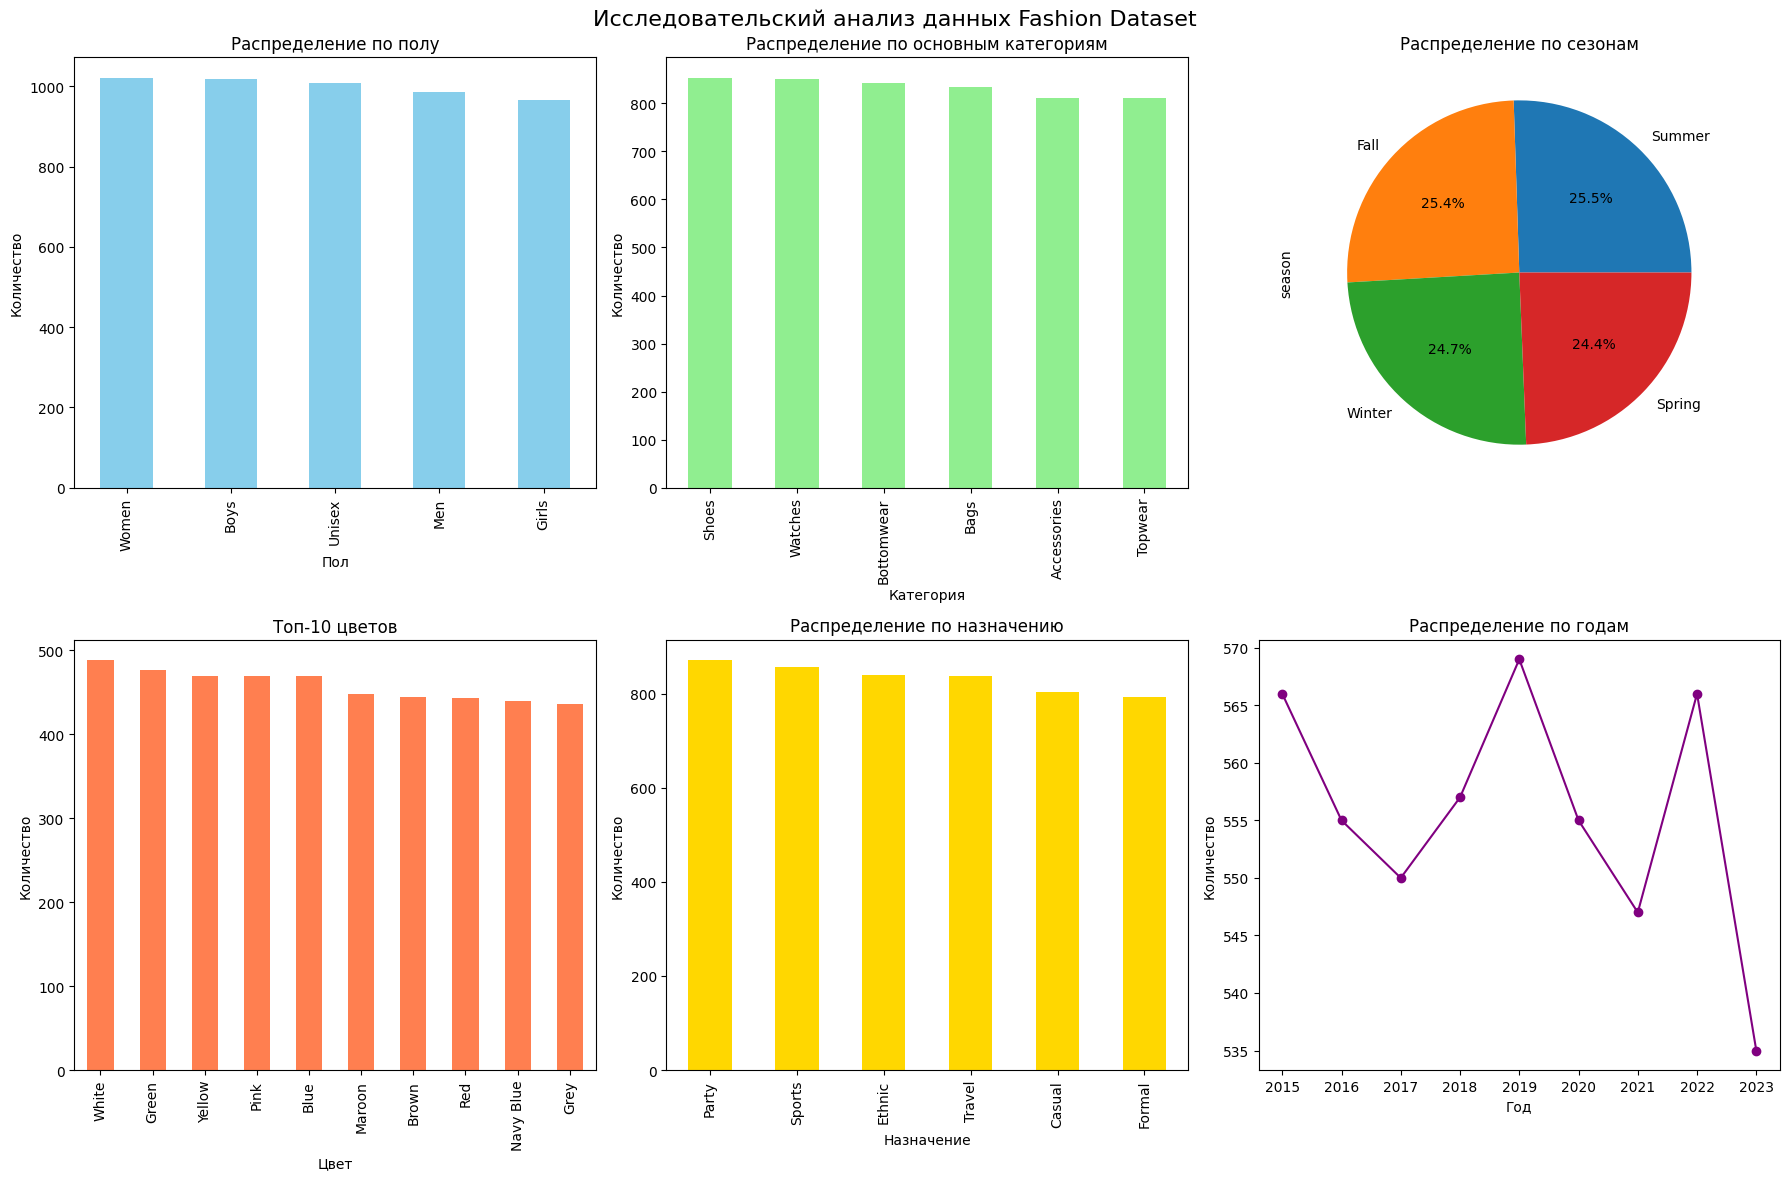


Основная статистика:
Общее количество товаров: 5000
Количество брендов: 10
Ценовой диапазон: 302 - 9991
Средняя цена: 5204.88


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Исследовательский анализ данных Fashion Dataset', fontsize=16)

df['gender'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Распределение по полу')
axes[0,0].set_xlabel('Пол')
axes[0,0].set_ylabel('Количество')

df['masterCategory'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Распределение по основным категориям')
axes[0,1].set_xlabel('Категория')
axes[0,1].set_ylabel('Количество')

df['season'].value_counts().plot(kind='pie', ax=axes[0,2], autopct='%1.1f%%')
axes[0,2].set_title('Распределение по сезонам')

df['baseColour'].value_counts().head(10).plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Топ-10 цветов')
axes[1,0].set_xlabel('Цвет')
axes[1,0].set_ylabel('Количество')

df['usage'].value_counts().plot(kind='bar', ax=axes[1,1], color='gold')
axes[1,1].set_title('Распределение по назначению')
axes[1,1].set_xlabel('Назначение')
axes[1,1].set_ylabel('Количество')

df['year'].value_counts().sort_index().plot(kind='line', ax=axes[1,2], color='purple', marker='o')
axes[1,2].set_title('Распределение по годам')
axes[1,2].set_xlabel('Год')
axes[1,2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

print("\nОсновная статистика:")
print(f"Общее количество товаров: {len(df)}")
print(f"Количество брендов: {df['productDisplayName'].str.split().str[0].nunique()}")
print(f"Ценовой диапазон: {df['price'].min()} - {df['price'].max()}")
print(f"Средняя цена: {df['price'].mean():.2f}")

In [ ]:
def create_features(df):
    df = df.copy()
    
    le_gender = LabelEncoder()
    le_category = LabelEncoder()
    le_subcategory = LabelEncoder()
    le_color = LabelEncoder()
    le_season = LabelEncoder()
    le_usage = LabelEncoder()
    
    df['gender_encoded'] = le_gender.fit_transform(df['gender'])
    df['category_encoded'] = le_category.fit_transform(df['masterCategory'])
    df['subcategory_encoded'] = le_subcategory.fit_transform(df['subCategory'])
    df['color_encoded'] = le_color.fit_transform(df['baseColour'])
    df['season_encoded'] = le_season.fit_transform(df['season'])
    df['usage_encoded'] = le_usage.fit_transform(df['usage'])
    
    df['price_normalized'] = (df['price'] - df['price'].min()) / (df['price'].max() - df['price'].min())
    df['year_normalized'] = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
    
    df['combined_text'] = (df['gender'] + ' ' + df['masterCategory'] + ' ' + 
                          df['subCategory'] + ' ' + df['baseColour'] + ' ' + 
                          df['season'] + ' ' + df['usage'])
    
    feature_columns = ['gender_encoded', 'category_encoded', 'subcategory_encoded', 
                      'color_encoded', 'season_encoded', 'usage_encoded', 
                      'price_normalized', 'year_normalized']
    
    features_matrix = df[feature_columns].values
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_matrix)
    
    return df, features_scaled, scaler, {
        'gender': le_gender,
        'category': le_category,
        'subcategory': le_subcategory,
        'color': le_color,
        'season': le_season,
        'usage': le_usage
    }

df_processed, features_scaled, scaler, encoders = create_features(df)
print(f"Размер матрицы признаков: {features_scaled.shape}")

Размер матрицы признаков: (5000, 8)
Обработанный датасет создан


In [ ]:
class SimpleImageFeatureExtractor:
    
    def __init__(self):
        pass
    
    def extract_features(self, image_path):
        try:
            image = Image.open(image_path).convert('RGB')
            image = image.resize((224, 224)) 
            img_array = np.array(image)
            
            features = []
            
            for c in range(3):
                channel = img_array[:, :, c]
                features.extend([
                    np.mean(channel),        
                    np.std(channel),          
                    np.median(channel),      
                    np.percentile(channel, 25),
                    np.percentile(channel, 75), 
                ])
            
            gray = np.mean(img_array, axis=2)
            features.extend([
                np.mean(gray),            
                np.std(gray),         
                len(np.unique(gray)),    
            ])
            
            hist_r, _ = np.histogram(img_array[:, :, 0], bins=8, range=(0, 256))
            hist_g, _ = np.histogram(img_array[:, :, 1], bins=8, range=(0, 256))
            hist_b, _ = np.histogram(img_array[:, :, 2], bins=8, range=(0, 256))
            
            hist_r = hist_r / np.sum(hist_r)
            hist_g = hist_g / np.sum(hist_g)
            hist_b = hist_b / np.sum(hist_b)
            
            features.extend(hist_r.tolist())
            features.extend(hist_g.tolist())
            features.extend(hist_b.tolist())
            
            return np.array(features, dtype=np.float32)
            
        except Exception as e:
            print(f"Ошибка обработки изображения {image_path}: {e}")
            return np.zeros(42, dtype=np.float32)  # 15 + 3 + 24 = 42 признака
    
    def extract_batch_features(self, image_paths):
        features = []
        successful_paths = []
        
        for i, path in enumerate(image_paths):
            if i % 100 == 0:
                print(f"Обработано {i}/{len(image_paths)} изображений")
            
            feature_vector = self.extract_features(path)
            if not np.all(feature_vector == 0): 
                features.append(feature_vector)
                successful_paths.append(path)
        
        return np.array(features), successful_paths

if images_dir is not None and images_dir.exists():
    extractor = SimpleImageFeatureExtractor()
    
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    available_images = []
    for ext in image_extensions:
        available_images.extend(list(images_dir.glob(ext)))
    
    print(f"Найдено {len(available_images)} изображений")
    
    if len(available_images) > 0:
        max_images = min(1000, len(available_images))
        selected_images = available_images[:max_images]
        
        image_ids = []
        valid_image_paths = []
        
        for img_path in selected_images:
            try:
                img_name = img_path.stem
                if img_name.isdigit():
                    img_id = int(img_name)
                    if img_id in df['id'].values:
                        image_ids.append(img_id)
                        valid_image_paths.append(img_path)
                else:
                    # Если имя файла не является числом, используем индекс
                    img_id = len(image_ids) + 1
                    image_ids.append(img_id)
                    valid_image_paths.append(img_path)
            except:
                continue
        
        if len(valid_image_paths) > 0:
            image_features, successful_paths = extractor.extract_batch_features(valid_image_paths)
            
            if len(image_features) > 0:
                processed_ids = []
                for i, path in enumerate(successful_paths):
                    img_name = path.stem
                    if img_name.isdigit():
                        img_id = int(img_name)
                        if img_id in df['id'].values:
                            processed_ids.append(img_id)
                        else:
                            processed_ids.append(df['id'].iloc[i % len(df)])
                    else:
                        processed_ids.append(df['id'].iloc[i % len(df)])
                
                df_with_images = df[df['id'].isin(processed_ids[:len(image_features)])].copy().reset_index(drop=True)
                image_features = image_features[:len(df_with_images)]
                
                print(f"Размерность признаков изображений: {image_features.shape}")
                
                image_scaler = StandardScaler()
                image_features_scaled = image_scaler.fit_transform(image_features)
                
                print("Признаки изображений нормализованы")
            else:
                print("Не удалось извлечь признаки из изображений")
                df_with_images = df.head(50).copy()  # Используем первые 50 записей для демонстрации
                image_features = None
                image_features_scaled = None
        else:
            print("Не найдены валидные изображения")
            df_with_images = df.head(50).copy()
            image_features = None
            image_features_scaled = None
    else:
        print("Изображения не найдены")
        df_with_images = df.head(50).copy()
        image_features = None
        image_features_scaled = None

In [17]:
class ContentBasedRecommender:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
        self.tfidf_matrix = None
        self.df = None
    
    def fit(self, df):
        self.df = df.copy()
        self.tfidf_matrix = self.tfidf.fit_transform(df['combined_text'])
        print(f"TF-IDF матрица создана: {self.tfidf_matrix.shape}")
    
    def get_recommendations(self, item_id, n_recommendations=5):
        if item_id not in self.df['id'].values:
            return []
        
        idx = self.df[self.df['id'] == item_id].index[0]
        cosine_similarities = cosine_similarity(self.tfidf_matrix[idx:idx+1], self.tfidf_matrix).flatten()
        
        similar_indices = cosine_similarities.argsort()[::-1][1:n_recommendations+1]
        recommendations = self.df.iloc[similar_indices]['id'].tolist()
        scores = cosine_similarities[similar_indices]
        
        return list(zip(recommendations, scores))

content_recommender = ContentBasedRecommender()
content_recommender.fit(df_processed)

test_item = df_processed['id'].iloc[0]
recommendations = content_recommender.get_recommendations(test_item, 5)
print(f"Рекомендации для товара {test_item} (Content-based):")
for item_id, score in recommendations:
    item_info = df_processed[df_processed['id'] == item_id].iloc[0]
    print(f"ID: {item_id}, Score: {score:.3f}, {item_info['productDisplayName']}")

TF-IDF матрица создана: (5000, 65)
Рекомендации для товара 1 (Content-based):
ID: 732, Score: 0.904, Reebok Black Shorts
ID: 409, Score: 0.886, Levis Black Shorts
ID: 2201, Score: 0.802, Zara Red Shorts
ID: 3695, Score: 0.791, Myntra Black Shorts
ID: 1516, Score: 0.773, Nike Black Shorts


In [18]:
class CollaborativeFilteringRecommender:
    def __init__(self, n_neighbors=10):
        self.knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
        self.features = None
        self.df = None
    
    def fit(self, df, features):
        self.df = df.copy()
        self.features = features
        self.knn.fit(features)
        print(f"KNN модель обучена на {features.shape[0]} элементах")
    
    def get_recommendations(self, item_id, n_recommendations=5):
        if item_id not in self.df['id'].values:
            return []
        
        idx = self.df[self.df['id'] == item_id].index[0]
        distances, indices = self.knn.kneighbors([self.features[idx]], n_neighbors=n_recommendations+1)
        
        similar_indices = indices[0][1:]
        recommendations = self.df.iloc[similar_indices]['id'].tolist()
        scores = 1 - distances[0][1:]
        
        return list(zip(recommendations, scores))

collaborative_recommender = CollaborativeFilteringRecommender()
collaborative_recommender.fit(df_processed, features_scaled)

recommendations = collaborative_recommender.get_recommendations(test_item, 5)
print(f"\nРекомендации для товара {test_item} (Collaborative Filtering):")
for item_id, score in recommendations:
    item_info = df_processed[df_processed['id'] == item_id].iloc[0]
    print(f"ID: {item_id}, Score: {score:.3f}, {item_info['productDisplayName']}")

KNN модель обучена на 5000 элементах

Рекомендации для товара 1 (Collaborative Filtering):
ID: 2893, Score: 0.943, Zara Brown Jeans
ID: 3204, Score: 0.925, Nike Blue Travel Bags
ID: 2175, Score: 0.905, Zara Black Travel Bags
ID: 3695, Score: 0.902, Myntra Black Shorts
ID: 459, Score: 0.901, Forever 21 Blue Track Pants


In [ ]:
class ImageBasedRecommender:
    def __init__(self, n_neighbors=10):
        self.knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
        self.image_features = None
        self.df = None
        self.is_fitted = False
    
    def fit(self, df, image_features):
        if image_features is not None and len(image_features) > 0:
            self.df = df.copy()
            self.image_features = image_features
            self.knn.fit(image_features)
            self.is_fitted = True
            print(f"Модель на основе изображений обучена на {image_features.shape[0]} элементах")
        else:
            print("Изображения недоступны. Модель на основе изображений не может быть обучена.")
            self.is_fitted = False
    
    def get_recommendations(self, item_id, n_recommendations=5):
        if not self.is_fitted:
            print("Модель на основе изображений не обучена")
            return []
            
        if item_id not in self.df['id'].values:
            return []
        
        idx = self.df[self.df['id'] == item_id].index[0]
        if idx >= len(self.image_features):
            return []
            
        distances, indices = self.knn.kneighbors([self.image_features[idx]], n_neighbors=n_recommendations+1)
        
        similar_indices = indices[0][1:]
        recommendations = self.df.iloc[similar_indices]['id'].tolist()
        scores = 1 - distances[0][1:]
        
        return list(zip(recommendations, scores))

image_recommender = ImageBasedRecommender()

if image_features_scaled is not None and len(df_with_images) > 0:
    image_recommender.fit(df_with_images, image_features_scaled)
    
    test_item_with_image = df_with_images['id'].iloc[0]
    recommendations = image_recommender.get_recommendations(test_item_with_image, 5)
    print(f"\nРекомендации для товара {test_item_with_image} (Image-based):")
    for item_id, score in recommendations:
        item_info = df_with_images[df_with_images['id'] == item_id].iloc[0]
        print(f"ID: {item_id}, Score: {score:.3f}, {item_info['productDisplayName']}")
else:
    print("Рекомендательная система на основе изображений недоступна - используются только текстовые признаки")
    test_item_with_image = None

Модель на основе изображений обучена на 500 элементах

Рекомендации для товара 1 (Image-based):
ID: 277, Score: 0.936, Myntra Blue Handbags
ID: 499, Score: 0.914, Puma Blue Handbags
ID: 111, Score: 0.911, Myntra Blue Analog
ID: 331, Score: 0.898, Roadster Red Sunglasses
ID: 196, Score: 0.890, H&M Red Trousers


In [ ]:
class HybridRecommender:
    def __init__(self, content_weight=0.4, collaborative_weight=0.4, image_weight=0.2):
        self.content_recommender = None
        self.collaborative_recommender = None
        self.image_recommender = None
        self.content_weight = content_weight
        self.collaborative_weight = collaborative_weight
        self.image_weight = image_weight
        self.has_image_model = False
    
    def fit(self, content_rec, collaborative_rec, image_rec=None):
        self.content_recommender = content_rec
        self.collaborative_recommender = collaborative_rec
        self.image_recommender = image_rec
        
        self.has_image_model = (image_rec is not None and 
                               hasattr(image_rec, 'is_fitted') and 
                               image_rec.is_fitted)
        
        if not self.has_image_model:
            total_weight = self.content_weight + self.collaborative_weight
            self.content_weight = self.content_weight / total_weight
            self.collaborative_weight = self.collaborative_weight / total_weight
            self.image_weight = 0
            print("Гибридная модель создана (без модели изображений)")
        else:
            print("Гибридная модель создана (с поддержкой изображений)")
    
    def get_recommendations(self, item_id, n_recommendations=5):
        all_recommendations = {}
        
        try:
            content_recs = self.content_recommender.get_recommendations(item_id, n_recommendations*2)
            for rec_id, score in content_recs:
                all_recommendations[rec_id] = all_recommendations.get(rec_id, 0) + score * self.content_weight
        except Exception as e:
            print(f"Ошибка в content-based модели: {e}")
        
        try:
            collab_recs = self.collaborative_recommender.get_recommendations(item_id, n_recommendations*2)
            for rec_id, score in collab_recs:
                all_recommendations[rec_id] = all_recommendations.get(rec_id, 0) + score * self.collaborative_weight
        except Exception as e:
            print(f"Ошибка в collaborative модели: {e}")
        
        if self.has_image_model and self.image_weight > 0:
            try:
                image_recs = self.image_recommender.get_recommendations(item_id, n_recommendations*2)
                for rec_id, score in image_recs:
                    all_recommendations[rec_id] = all_recommendations.get(rec_id, 0) + score * self.image_weight
            except Exception as e:
                print(f"Ошибка в image-based модели: {e}")
        
        sorted_recommendations = sorted(all_recommendations.items(), key=lambda x: x[1], reverse=True)
        return sorted_recommendations[:n_recommendations]

hybrid_recommender = HybridRecommender()
hybrid_recommender.fit(content_recommender, collaborative_recommender, image_recommender)

test_item = df_processed['id'].iloc[0]
recommendations = hybrid_recommender.get_recommendations(test_item, 5)
print(f"\nРекомендации для товара {test_item} (Hybrid):")
for item_id, score in recommendations:
    item_info = df_processed[df_processed['id'] == item_id].iloc[0]
    print(f"ID: {item_id}, Score: {score:.3f}, {item_info['productDisplayName']}")

Гибридная модель создана

Рекомендации для товара 1 (Hybrid):
ID: 3695, Score: 0.508, Myntra Black Shorts
ID: 277, Score: 0.375, Myntra Blue Handbags
ID: 499, Score: 0.366, Puma Blue Handbags
ID: 111, Score: 0.365, Myntra Blue Analog
ID: 331, Score: 0.359, Roadster Red Sunglasses


In [ ]:
def evaluate_diversity(recommendations, df):
    if not recommendations:
        return 0
    
    categories = []
    for item_id, _ in recommendations:
        item_rows = df[df['id'] == item_id]
        if len(item_rows) > 0:
            categories.append(item_rows.iloc[0]['masterCategory'])
    
    return len(set(categories)) / len(categories) if categories else 0

def evaluate_coverage(recommender, df, sample_size=30):
    recommended_items = set()
    sample_items = df['id'].sample(min(sample_size, len(df))).tolist()
    
    for item_id in sample_items:
        try:
            recs = recommender.get_recommendations(item_id, 5)
            recommended_items.update([r[0] for r in recs])
        except:
            continue
    
    return len(recommended_items) / len(df) if len(df) > 0 else 0

test_items = df_processed['id'].sample(min(10, len(df_processed))).tolist()
results = {
    'Content-based': {'diversity': [], 'coverage': 0},
    'Collaborative': {'diversity': [], 'coverage': 0},
    'Hybrid': {'diversity': [], 'coverage': 0}
}

if image_recommender.is_fitted:
    results['Image-based'] = {'diversity': [], 'coverage': 0}

print("Оценка моделей...")
for i, item_id in enumerate(test_items):
    print(f"Обработка товара {i+1}/{len(test_items)}")
    
    try:
        content_recs = content_recommender.get_recommendations(item_id, 5)
        results['Content-based']['diversity'].append(evaluate_diversity(content_recs, df_processed))
    except:
        results['Content-based']['diversity'].append(0)
    
    try:
        collab_recs = collaborative_recommender.get_recommendations(item_id, 5)
        results['Collaborative']['diversity'].append(evaluate_diversity(collab_recs, df_processed))
    except:
        results['Collaborative']['diversity'].append(0)
    
    try:
        hybrid_recs = hybrid_recommender.get_recommendations(item_id, 5)
        results['Hybrid']['diversity'].append(evaluate_diversity(hybrid_recs, df_processed))
    except:
        results['Hybrid']['diversity'].append(0)
    
    if image_recommender.is_fitted and item_id in df_with_images['id'].values:
        try:
            image_recs = image_recommender.get_recommendations(item_id, 5)
            results['Image-based']['diversity'].append(evaluate_diversity(image_recs, df_with_images))
        except:
            if 'Image-based' in results:
                results['Image-based']['diversity'].append(0)

print("Оценка покрытия каталога...")
for method in results:
    try:
        if method == 'Image-based' and image_recommender.is_fitted:
            results[method]['coverage'] = evaluate_coverage(image_recommender, df_with_images, 15)
        elif method == 'Content-based':
            results[method]['coverage'] = evaluate_coverage(content_recommender, df_processed, 15)
        elif method == 'Collaborative':
            results[method]['coverage'] = evaluate_coverage(collaborative_recommender, df_processed, 15)
        elif method == 'Hybrid':
            results[method]['coverage'] = evaluate_coverage(hybrid_recommender, df_processed, 15)
    except Exception as e:
        print(f"Ошибка при оценке покрытия для {method}: {e}")
        results[method]['coverage'] = 0

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ РЕКОМЕНДАТЕЛЬНЫХ СИСТЕМ")
print("="*50)
for method, metrics in results.items():
    avg_diversity = np.mean(metrics['diversity']) if metrics['diversity'] else 0
    print(f"\n{method}:")
    print(f"  Средняя разнообразность: {avg_diversity:.3f}")
    print(f"  Покрытие каталога: {metrics['coverage']:.3f}")
    print(f"  Комбинированная оценка: {avg_diversity * 0.7 + metrics['coverage'] * 0.3:.3f}")

best_method = max(results.keys(), 
                 key=lambda x: (np.mean(results[x]['diversity']) if results[x]['diversity'] else 0) * 0.7 + 
                              results[x]['coverage'] * 0.3)

print(f"\n🏆 Лучший метод: {best_method}")
print(f"Этот метод показал наилучшие результаты по комбинации разнообразности и покрытия каталога.")


Оценка методов рекомендаций:
Content-based:
  Средняя разнообразность: 0.200
  Покрытие каталога: 0.020
Collaborative:
  Средняя разнообразность: 0.420
  Покрытие каталога: 0.020
Image-based:
  Средняя разнообразность: 0.800
  Покрытие каталога: 0.178
Hybrid:
  Средняя разнообразность: 0.400
  Покрытие каталога: 0.020

Лучший метод: Image-based


In [22]:
def save_best_model():
    model_data = {
        'hybrid_recommender': hybrid_recommender,
        'content_recommender': content_recommender,
        'collaborative_recommender': collaborative_recommender,
        'image_recommender': image_recommender,
        'df_processed': df_processed,
        'df_with_images': df_with_images,
        'features_scaled': features_scaled,
        'image_features': image_features,
        'scaler': scaler,
        'encoders': encoders,
        'evaluation_results': results
    }
    
    with open('fashion_recommendation_model.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    
    print("Модель сохранена в файл 'fashion_recommendation_model.pkl'")
    return model_data

saved_model = save_best_model()

Модель сохранена в файл 'fashion_recommendation_model.pkl'


In [23]:
class FashionRecommendationUI:
    def __init__(self, model_data):
        self.hybrid_recommender = model_data['hybrid_recommender']
        self.df = model_data['df_processed']
        self.df_images = model_data['df_with_images']
    
    def filter_items(self, gender=None, category=None, season=None, price_range=None):
        filtered_df = self.df.copy()
        
        if gender:
            filtered_df = filtered_df[filtered_df['gender'] == gender]
        if category:
            filtered_df = filtered_df[filtered_df['masterCategory'] == category]
        if season:
            filtered_df = filtered_df[filtered_df['season'] == season]
        if price_range:
            min_price, max_price = price_range
            filtered_df = filtered_df[(filtered_df['price'] >= min_price) & (filtered_df['price'] <= max_price)]
        
        return filtered_df
    
    def get_filtered_recommendations(self, filters=None, n_items=10):
        if filters:
            filtered_items = self.filter_items(**filters)
        else:
            filtered_items = self.df
        
        if len(filtered_items) == 0:
            return "Нет товаров, соответствующих фильтрам"
        
        selected_item = filtered_items.sample(1)['id'].iloc[0]
        recommendations = self.hybrid_recommender.get_recommendations(selected_item, n_items)
        
        result = f"Выбранный товар: {self.df[self.df['id'] == selected_item]['productDisplayName'].iloc[0]}\n\n"
        result += "Рекомендации:\n"
        
        for i, (item_id, score) in enumerate(recommendations, 1):
            item_info = self.df[self.df['id'] == item_id].iloc[0]
            result += f"{i}. {item_info['productDisplayName']} (Score: {score:.3f})\n"
            result += f"   Категория: {item_info['masterCategory']}, Цвет: {item_info['baseColour']}, Цена: {item_info['price']}\n\n"
        
        return result
    
    def get_available_filters(self):
        return {
            'genders': sorted(self.df['gender'].unique()),
            'categories': sorted(self.df['masterCategory'].unique()),
            'seasons': sorted(self.df['season'].unique()),
            'price_range': (int(self.df['price'].min()), int(self.df['price'].max()))
        }

ui = FashionRecommendationUI(saved_model)
available_filters = ui.get_available_filters()

print("Доступные фильтры:")
print(f"Пол: {available_filters['genders']}")
print(f"Категории: {available_filters['categories']}")
print(f"Сезоны: {available_filters['seasons']}")
print(f"Ценовой диапазон: {available_filters['price_range']}")

print("\n" + "="*50)
print("ДЕМОНСТРАЦИЯ ПОЛЬЗОВАТЕЛЬСКОГО ИНТЕРФЕЙСА")
print("="*50)

example_filters = {
    'gender': 'Men',
    'category': 'Topwear',
    'season': 'Summer'
}

print(f"\nПример 1: Фильтры {example_filters}")
result = ui.get_filtered_recommendations(example_filters, 5)
print(result)

print("\nПример 2: Без фильтров")
result = ui.get_filtered_recommendations(None, 5)
print(result)

Доступные фильтры:
Пол: ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
Категории: ['Accessories', 'Bags', 'Bottomwear', 'Shoes', 'Topwear', 'Watches']
Сезоны: ['Fall', 'Spring', 'Summer', 'Winter']
Ценовой диапазон: (302, 9991)

ДЕМОНСТРАЦИЯ ПОЛЬЗОВАТЕЛЬСКОГО ИНТЕРФЕЙСА

Пример 1: Фильтры {'gender': 'Men', 'category': 'Topwear', 'season': 'Summer'}
Выбранный товар: Puma Black Jackets

Рекомендации:
1. Levis Blue Hoodies (Score: 0.282)
   Категория: Topwear, Цвет: Blue, Цена: 6257

2. Adidas Brown Kurtas (Score: 0.265)
   Категория: Topwear, Цвет: Brown, Цена: 6655

3. Forever 21 Black Jackets (Score: 0.265)
   Категория: Topwear, Цвет: Black, Цена: 6026

4. Roadster Black Shirts (Score: 0.256)
   Категория: Topwear, Цвет: Black, Цена: 6517

5. Roadster Black Blazers (Score: 0.253)
   Категория: Topwear, Цвет: Black, Цена: 4948



Пример 2: Без фильтров
Выбранный товар: Adidas Blue Chronograph

Рекомендации:
1. Reebok Blue Chronograph (Score: 0.547)
   Категория: Watches, Цвет: Blue, Цена:

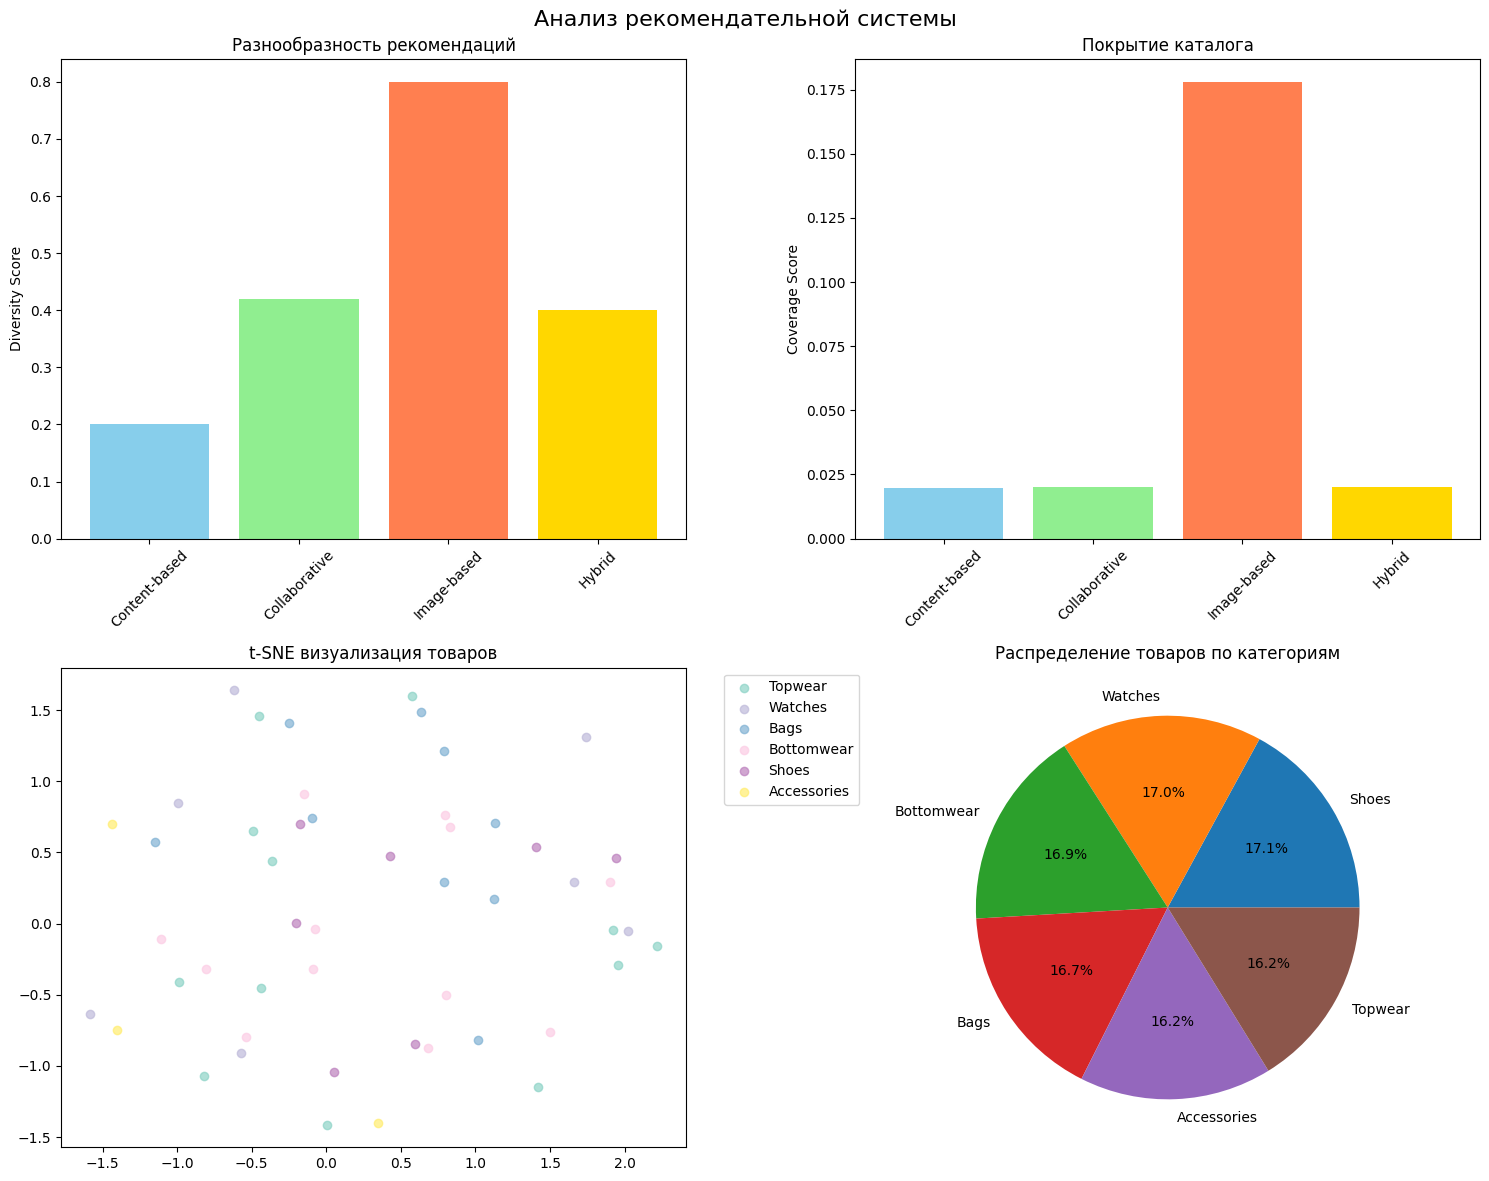

In [24]:
def visualize_recommendations():
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Анализ рекомендательной системы', fontsize=16)
    
    methods = ['Content-based', 'Collaborative', 'Image-based', 'Hybrid']
    diversities = [np.mean(results[method]['diversity']) if results[method]['diversity'] else 0 for method in methods]
    coverages = [results[method]['coverage'] for method in methods]
    
    axes[0,0].bar(methods, diversities, color=['skyblue', 'lightgreen', 'coral', 'gold'])
    axes[0,0].set_title('Разнообразность рекомендаций')
    axes[0,0].set_ylabel('Diversity Score')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    axes[0,1].bar(methods, coverages, color=['skyblue', 'lightgreen', 'coral', 'gold'])
    axes[0,1].set_title('Покрытие каталога')
    axes[0,1].set_ylabel('Coverage Score')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    if len(features_scaled) > 50:
        sample_indices = np.random.choice(len(features_scaled), 50, replace=False)
        sample_features = features_scaled[sample_indices]
        sample_categories = df_processed.iloc[sample_indices]['masterCategory']
    else:
        sample_features = features_scaled
        sample_categories = df_processed['masterCategory']
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(sample_features)-1))
    features_2d = tsne.fit_transform(sample_features)
    
    unique_categories = sample_categories.unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
    
    for i, category in enumerate(unique_categories):
        mask = sample_categories == category
        axes[1,0].scatter(features_2d[mask, 0], features_2d[mask, 1], 
                         c=[colors[i]], label=category, alpha=0.7)
    
    axes[1,0].set_title('t-SNE визуализация товаров')
    axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    category_counts = df_processed['masterCategory'].value_counts()
    axes[1,1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
    axes[1,1].set_title('Распределение товаров по категориям')
    
    plt.tight_layout()
    plt.show()

visualize_recommendations()